In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import pandas_ta as ta
# Daten einlesen
df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv')

In [66]:
# Adding indicators

df['target_bruehler_straße'] = df['bruehler_straße'].shift(-1)

df.dropna(inplace=True)
# Zeiteigenschaften setzen und Index machen
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time')

df.head()

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer,target_bruehler_straße
time,,,,,,,,,,
2016-01-16 00:00:00,5,0,36,1,3,5,2,3,1,4.0
2016-01-16 01:00:00,4,0,44,3,4,4,2,3,4,0.0
2016-01-16 02:00:00,0,0,26,3,3,3,0,3,2,3.0
2016-01-16 03:00:00,3,0,15,0,0,0,0,0,0,1.0
2016-01-16 04:00:00,1,0,22,3,1,2,0,0,1,1.0


In [67]:
data_set = df.iloc[:, 0:11]#.values
pd.set_option('display.max_columns', None)

data_set.head(20)
#print(data_set.shape)
#print(data.shape)
#print(type(data_set))

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer,target_bruehler_straße
time,,,,,,,,,,
2016-01-16 00:00:00,5,0,36,1,3,5,2,3,1,4.0
2016-01-16 01:00:00,4,0,44,3,4,4,2,3,4,0.0
2016-01-16 02:00:00,0,0,26,3,3,3,0,3,2,3.0
2016-01-16 03:00:00,3,0,15,0,0,0,0,0,0,1.0
2016-01-16 04:00:00,1,0,22,3,1,2,0,0,1,1.0
2016-01-16 05:00:00,1,0,14,2,10,1,0,0,5,4.0
2016-01-16 06:00:00,4,0,23,5,6,0,0,0,3,4.0
2016-01-16 07:00:00,4,1,25,3,8,2,1,3,7,9.0
2016-01-16 08:00:00,9,2,57,7,16,8,4,3,12,20.0


In [68]:
#Target column Categories
#y =[1 if data.Open[i]>data.Close[i] else 0 for i in range(0, len(data))]
#yi = [data.Open[i]-data.Close[i] for i in range(0, len(data))]
#print(yi)
#print(len(yi))

In [69]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
data_set_scaled = sc.fit_transform(data_set)
print(data_set_scaled)

[[0.00424088 0.         0.01079137 ... 0.00262238 0.00081433 0.00339271]
 [0.00339271 0.         0.01318945 ... 0.00262238 0.00325733 0.        ]
 [0.         0.         0.00779376 ... 0.00262238 0.00162866 0.00254453]
 ...
 [0.01102629 0.         0.02967626 ... 0.00874126 0.01058632 0.01102629]
 [0.01102629 0.         0.02068345 ... 0.01048951 0.01058632 0.01102629]
 [0.01102629 0.         0.01378897 ... 0.00437063 0.00895765 0.01102629]]


In [70]:
# multiple feature from data provided to the model
X = []
#print(data_set_scaled[0].size)
#data_set_scaled=data_set.values
backcandles = 24
print(data_set_scaled.shape[0])
for j in range(9):#data_set_scaled[0].size):#2 columns are target not X
    X.append([])
    for i in range(backcandles, data_set_scaled.shape[0]):#backcandles+2
        X[j].append(data_set_scaled[i-backcandles:i, j])

#move axis from 0 to position 2
X=np.moveaxis(X, [0], [2])

#Erase first elements of y because of backcandles to match X length
#del(yi[0:backcandles])
#X, yi = np.array(X), np.array(yi)
# Choose -1 for last column, classification else -2...
X, yi =np.array(X), np.array(data_set_scaled[backcandles:,-1])
y=np.reshape(yi,(len(yi),1))
#y=sc.fit_transform(yi)
#X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X)
print(X.shape)
print(y)
print(y.shape)

69744
[[[0.00424088 0.         0.01079137 ... 0.00188857 0.00262238 0.00081433]
  [0.00339271 0.         0.01318945 ... 0.00188857 0.00262238 0.00325733]
  [0.         0.         0.00779376 ... 0.         0.00262238 0.00162866]
  ...
  [0.00508906 0.         0.02098321 ... 0.00283286 0.00262238 0.002443  ]
  [0.00593723 0.         0.01318945 ... 0.         0.00262238 0.00162866]
  [0.00169635 0.         0.01708633 ... 0.00188857 0.00174825 0.00570033]]

 [[0.00339271 0.         0.01318945 ... 0.00188857 0.00262238 0.00325733]
  [0.         0.         0.00779376 ... 0.         0.00262238 0.00162866]
  [0.00254453 0.         0.0044964  ... 0.         0.         0.        ]
  ...
  [0.00593723 0.         0.01318945 ... 0.         0.00262238 0.00162866]
  [0.00169635 0.         0.01708633 ... 0.00188857 0.00174825 0.00570033]
  [0.00169635 0.00156495 0.01888489 ... 0.00094429 0.         0.00081433]]

 [[0.         0.         0.00779376 ... 0.         0.00262238 0.00162866]
  [0.00254453 0.

In [71]:
#also comprehensions for X
#X = np.array([data_set_scaled[i-backcandles:i,:4].copy() for i in range(backcandles,len(data_set_scaled))])
#print(X)
#print(X.shape)

In [72]:
# split data into train test sets
splitlimit = int(len(X)*0.8)
print(splitlimit)
X_train, X_test = X[:splitlimit], X[splitlimit:]
y_train, y_test = y[:splitlimit], y[splitlimit:]
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train)

55776
(55776, 24, 9)
(13944, 24, 9)
(55776, 1)
(13944, 1)
[[0.00254453]
 [0.00254453]
 [0.00084818]
 ...
 [0.01017812]
 [0.00763359]
 [0.00508906]]


In [73]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import TimeDistributed

import tensorflow as tf
import keras
from keras import optimizers
from keras.callbacks import History
from keras.models import Model
from keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
import numpy as np
#tf.random.set_seed(20)
#np.random.seed(10)

lstm_input = Input(shape=(backcandles, 9), name='lstm_input')
inputs = LSTM(150, name='first_layer')(lstm_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('linear', name='output')(inputs)
model = Model(inputs=lstm_input, outputs=output)
adam = optimizers.Adam()
model.compile(optimizer=adam, loss='mse', metrics=['mae'])
early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='lstm_bruehler_straße.keras', monitor='val_loss', save_best_only=True)
model_bruehler_straße = model.fit(x=X_train, y=y_train, batch_size=128, epochs=1000, shuffle=True, validation_split = 0.1, callbacks=[early, check])

Epoch 1/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 3.9763e-04 - mae: 0.0144 - val_loss: 2.7385e-04 - val_mae: 0.0114
Epoch 2/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 2.3835e-04 - mae: 0.0108 - val_loss: 2.4934e-04 - val_mae: 0.0109
Epoch 3/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 2.1253e-04 - mae: 0.0101 - val_loss: 2.1682e-04 - val_mae: 0.0099
Epoch 4/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 1.9413e-04 - mae: 0.0097 - val_loss: 1.7756e-04 - val_mae: 0.0092
Epoch 5/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 1.6166e-04 - mae: 0.0088 - val_loss: 1.7166e-04 - val_mae: 0.0090
Epoch 6/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 1.4374e-04 - mae: 0.0083 - val_loss: 1.2969e-04 - val_mae: 0.0081
Epoch 7/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 1.3300e-04 - mae: 0.0080 - val_loss: 1.1953e-04 - val_mae: 0.0079
Epoch 8/1000
393/393 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 1.2012e-04 - mae: 0.0076 - val_lo

In [74]:
y_pred = model_bruehler_straße.predict(X_test)
#y_pred=np.where(y_pred > 0.43, 1,0)
for i in range(9):
    print(y_pred[i], y_test[i])

436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step
[0.00461619] [0.00084818]
[0.00297693] [0.00254453]
[0.00180884] [0.]
[0.00247532] [0.00084818]
[0.00258877] [0.00508906]
[0.00842312] [0.02290076]
[0.03865] [0.057676]
[0.11194804] [0.11704835]
[0.0892072] [0.10687023]


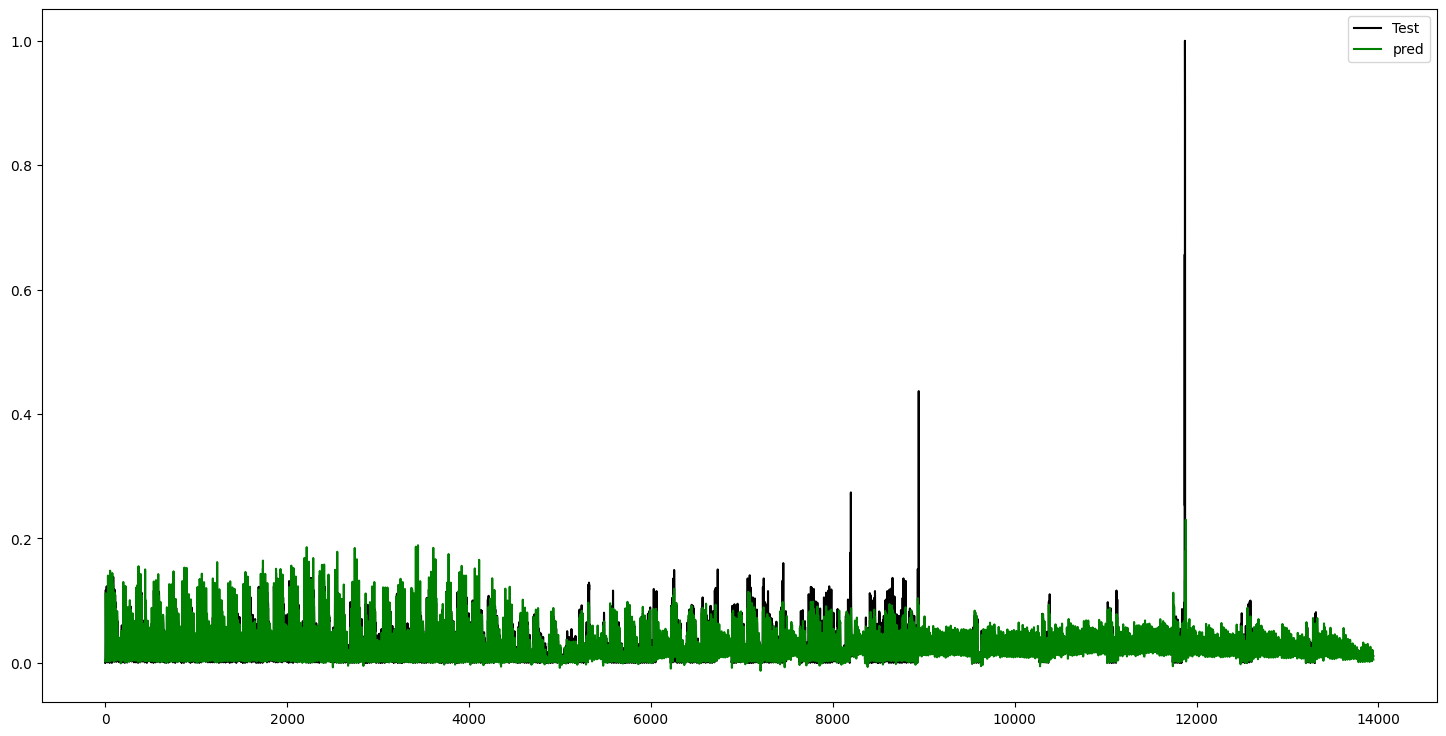

In [75]:
plt.figure(figsize=(18,9))
plt.plot(y_test, color = 'black', label = 'Test')
plt.plot(y_pred, color = 'green', label = 'pred')
plt.legend()
plt.show()

In [76]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_layer (LSTM)              │ (None, 150)            │        96,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 1)              │           151 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Activation)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,455 (1.10 MB)

 Trainable params: 96,151 (375.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 192,304 (751.19 KB)

Text(0, 0.5, 'loss')

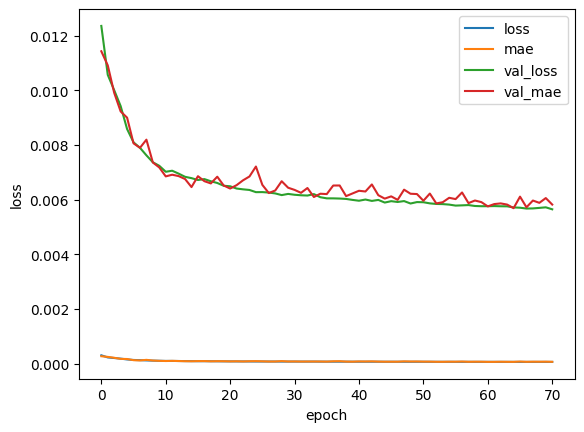

In [87]:
plt.plot(model_bruehler_straße.history['loss'])
plt.plot(model_bruehler_straße.history['val_loss'])
plt.plot(model_bruehler_straße.history['mae'])
plt.plot(model_bruehler_straße.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')